<a href="https://colab.research.google.com/github/SitiMutmainah15/PEMBELAJARAN-MESIN_GENAP_2026/blob/main/KUIS01_244107020143_SITI_MUTMAINAH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [2]:
# Install UCI REPO Library
!pip install -q ucimlrepo

In [3]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [4]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [5]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [6]:
# Data Size
df.shape

(48842, 15)

In [7]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [8]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       47879 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education-num   48842 non-null  int64 
 5   marital-status  48842 non-null  object
 6   occupation      47876 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital-gain    48842 non-null  int64 
 11  capital-loss    48842 non-null  int64 
 12  hours-per-week  48842 non-null  int64 
 13  native-country  48568 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,0
age,0
workclass,963
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,966
relationship,0
race,0
sex,0


Hasil inspeksi data menunjukkan bahwa dataset memiliki 48842 data dengan 15 variabel. Berdasarkan pengecekan terdapat tiga fitur yang memiliki data kosong adalah workclass 963 data, occupation 966 data, dan native-country 274 data

## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [9]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
df = df.replace('?', np.nan)
for col in df.columns:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].mode()[0])
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


Proses imputasi dilakukan pada fitur yang memiliki data hilang menggunakan nilai modus. Setelah dilakukan pengecekan ulang, seluruh variabel tidak memiliki missing value sehingga data siap digunakan.

## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [11]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
  print("kolom:", col)
  print(df[col].unique())
  print()

kolom: workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' 'Without-pay' 'Never-worked']

kolom: education
['Bachelors' 'HS-grad' '11th' 'Masters' '9th' 'Some-college' 'Assoc-acdm'
 'Assoc-voc' '7th-8th' 'Doctorate' 'Prof-school' '5th-6th' '10th'
 '1st-4th' 'Preschool' '12th']

kolom: marital-status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Married-spouse-absent'
 'Separated' 'Married-AF-spouse' 'Widowed']

kolom: occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Other-service' 'Sales' 'Craft-repair' 'Transport-moving'
 'Farming-fishing' 'Machine-op-inspct' 'Tech-support' 'Protective-serv'
 'Armed-Forces' 'Priv-house-serv']

kolom: relationship
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

kolom: race
['White' 'Black' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo' 'Other']

kolom: sex
['Male' 'Female']

kolom: native-country
['United-States' 'Cuba' 'Jamaica' 'India' 'Mexico' 'S

Hasil inspeksi menunjukkan setiap variabel kategori sudah memiliki nilai yang sesuai. Tidak ditemukan nilai yang tidak valid sehingga tidak diperlukan penggantian nilai menjadi others.

# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

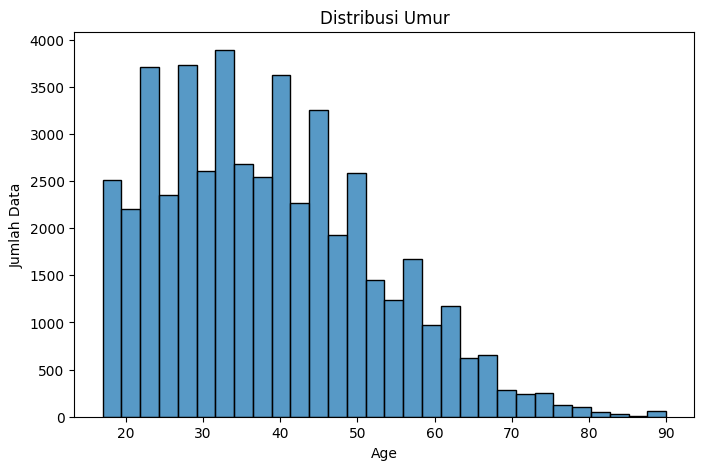

In [12]:
# Jawab 1.1 - Histrogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    bins=30
)
plt.title("Distribusi Umur")
plt.xlabel("Age")
plt.ylabel("Jumlah Data")
plt.show()

Berdasarkan hasil histogram, distribusi umur pada dataset berada pada rentang sekitar 17-90 tahun. Data paling banyak terdapat pada kelompok usia produktif sekitar 20–45 tahun. Setelah usia 50 tahun, jumlah data mulai mengalami penurunan dan semakin sedikit pada usia yang lebih tinggi.

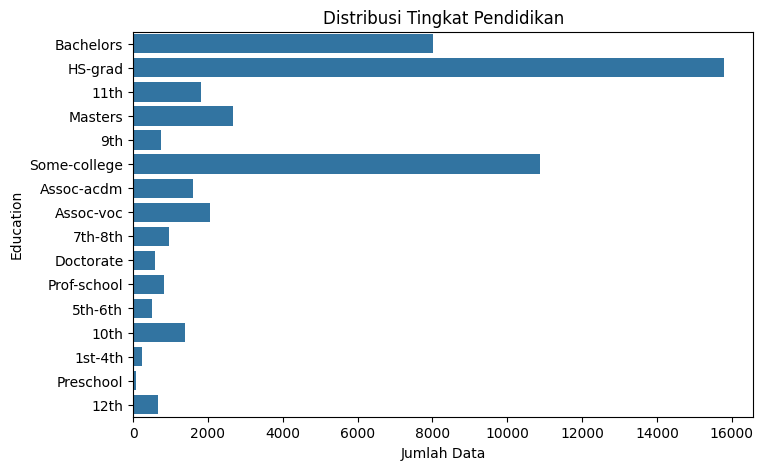

In [13]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    y='education'
)

plt.title("Distribusi Tingkat Pendidikan")
plt.xlabel("Jumlah Data")
plt.ylabel("Education")

plt.show()

Dari grafik terlihat bahwa tingkat pendidikan yang paling banyak terdapat pada kategori HS-grad dan Some-college. Sementara itu, kategori pendidikan Preschool, 1st-4th, dan Doctorate memiliki jumlah data yang lebih sedikit.

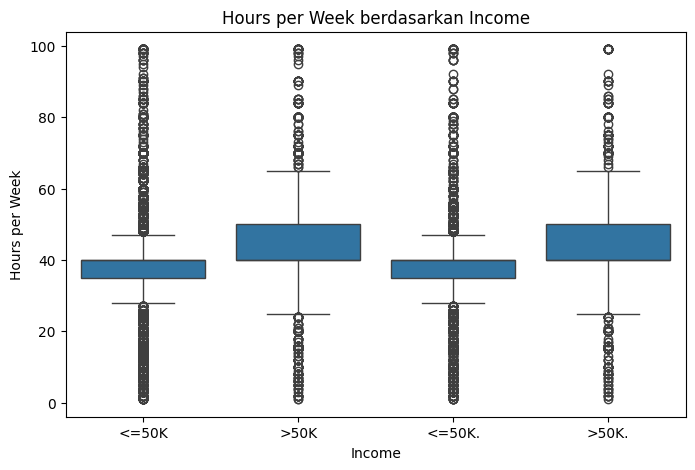

In [14]:
# Jawab 1.3 - Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='income',
    y='hours-per-week'
)

plt.title("Hours per Week berdasarkan Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")

plt.show()

Berdasarkan hasil boxplot, terlihat bahwa orang dengan income >50K cenderung bekerja lebih lama dibandingkan dengan kelompok income <=50K. Pada kedua kelompok juga terdapat beberapa data yang memiliki jam kerja berbeda jauh dari sebagian besar data lainnya.

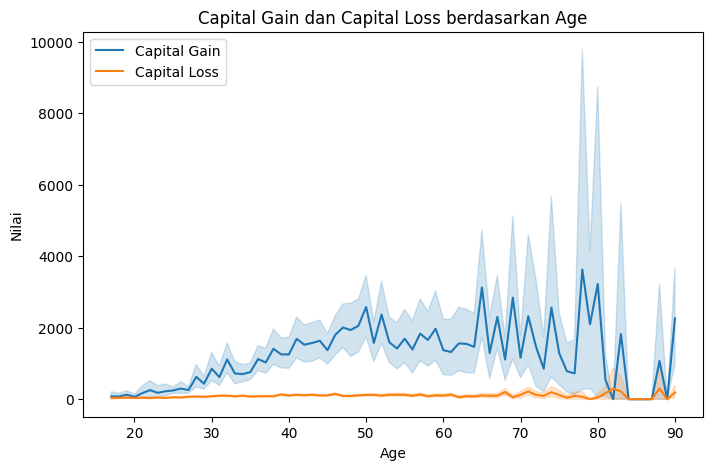

In [15]:
# Jawab 1.4 - Lineplot
plt.figure(figsize=(8,5))

sns.lineplot(
    data=df,
    x='age',
    y='capital-gain',
    label='Capital Gain'
)

sns.lineplot(
    data=df,
    x='age',
    y='capital-loss',
    label='Capital Loss'
)

plt.title("Capital Gain dan Capital Loss berdasarkan Age")
plt.xlabel("Age")
plt.ylabel("Nilai")

plt.legend()
plt.show()

Dari grafik terlihat bahwa nilai capital gain lebih tinggi dibandingkan capital loss pada sebagian besar kelompok umur. Terdapat beberapa kenaikan yang cukup besar pada usia tertentu, sedangkan capital loss cenderung memiliki nilai yang lebih rendah.

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [ ]:
# Jawab dengan komentar python

'''
1. Berdasarkan histogram age, distribusi umur pada dataset berada pada
rentang sekitar 17 sampai 90 tahun. Sebagian besar data berada pada usia produktif, terutama sekitar
20-45 tahun, kemudian jumlah data mulai menurun pada usia yang lebih tinggi.

2. Jika terdapat missing value pada variabel age, strategi yang dapat digunakan adalah
mengisi data menggunakan nilai median. Hal ini karena age merupakan data numerik dan
median dapat mengurangi pengaruh dari data yang terlalu jauh (outlier).

3. Berdasarkan boxplot hours-per-week terhadap income, kedua kategori income memiliki
beberapa outlier. Outlier terlihat pada kelompok jam kerja yang sangat rendah maupun
tinggi. Jumlah outlier dapat dilihat dari banyaknya titik yang berada di luar batas boxplot.
'''

'\n  Bisa dengan multiple comment\n  seperti ini\n'

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [16]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
# encoding kolom sex
df['sex'] = encoder.fit_transform(df['sex'])
# encoding kolom income sebagai target
df['income'] = encoder.fit_transform(df['income'])
# melihat hasil encoding
df[['sex', 'income']].head()

,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

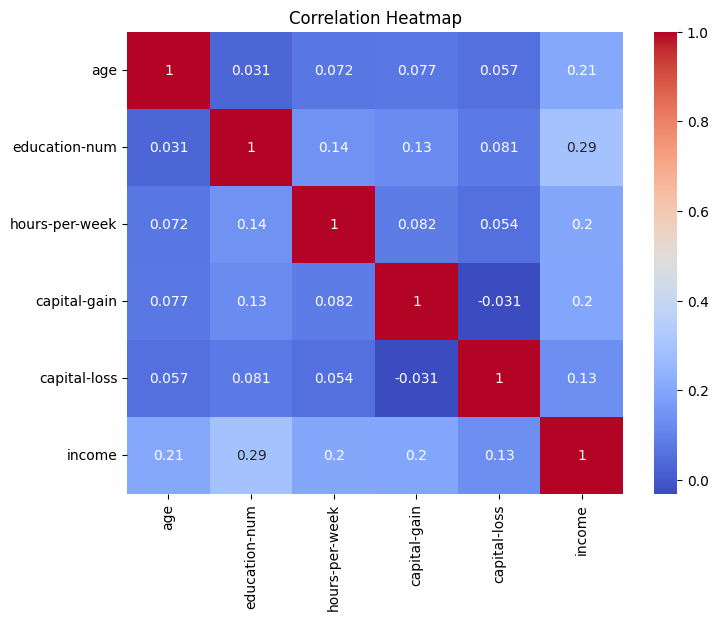

In [17]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
corr_data = df[
    [
        'age',
        'education-num',
        'hours-per-week',
        'capital-gain',
        'capital-loss',
        'income'
    ]
]
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Hasil analisis jelaskan pada cell ini
'''
Berdasarkan heatmap korelasi, education num memiliki hubungan positif paling tinggi
dengan income. Variabel lainnya memiliki hubungan yang lebih rendah terhadap income.
'''

# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [18]:
# Fetch data and inspect data shape
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt

# Load train & test split
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


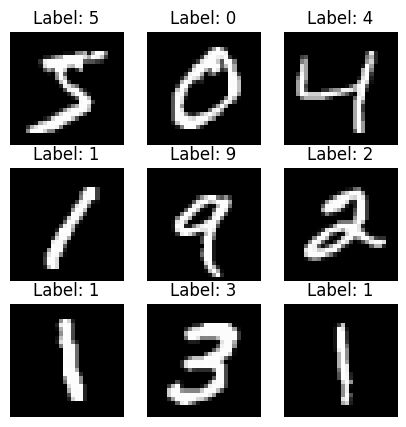

In [19]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

In [20]:
# Jawab Soal 1
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
from skimage.transform import resize
# buat array kosong
X_test_resize = np.zeros((10000, 32, 32))
# lakukan resize
for i in range(len(X_test)):
    X_test_resize[i] = resize(
        X_test[i],
        (32, 32)
    )
#lihat ukuran data setelah resize
X_test_resize.shape

(10000, 32, 32)

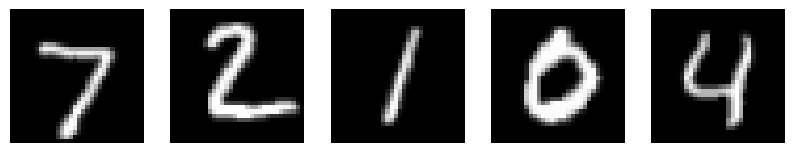

In [21]:
# menampilkan 5 hasil upsampling
plt.figure(figsize=(10,3))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test_resize[i], cmap="gray")
    plt.axis("off")

plt.show()

## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [22]:
# Jawab Soal 2
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
# normalisasi nilai pixel
X_test_normalized = X_test_resize / 255.0

# melihat hasil
X_test_normalized[0]

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [23]:
# Jawab Soal 3
# Kerjakan pada cell ini
# Anda diperbolehkan menambah cell jika diperlukan
# buat array kosong
X_test_flatten = np.zeros((10000, 1024))

# ubah setiap gambar jadi 1 dimensi
for i in range(len(X_test_normalized)):
    X_test_flatten[i] = X_test_normalized[i].flatten()

# lihat uk data setelah flatten
X_test_flatten.shape

(10000, 1024)